# FED History — Incapacitation Onset Analysis

This notebook reads the agent FED history CSV, identifies the time at which each agent transitions from `incapacitated = False` to `incapacitated = True`, and visualises the distribution of incapacitation onset times.

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

CSV_PATH = r"C:\Users\grego\Documents\Julich\PycharmProjects\pyFDS-Evac\results\Homogenous Test baby 2000\Homogenous Test baby 2000_fed_history.csv"

SyntaxError: unterminated string literal (detected at line 6) (2754856617.py, line 6)

## 1 — Load data

In [ ]:
df = pd.read_csv(
    r"C:\Users\grego\Documents\Julich\PycharmProjects\pyFDS-Evac\results\Homogenous Test baby 2000\Homogenous Test baby 2000_fed_history.csv"
)
print(
    f"Rows: {len(df):,}   Columns: {df.shape[1]}   Agents: {df['agent_id'].nunique()}"
)
df.head()

## 2 — Find incapacitation onset per agent

For each agent the onset time is the first timestep at which `incapacitated` switches from `False` to `True`.

In [26]:
transitions = []

for agent_id, group in df.groupby("agent_id"):
    group = group.sort_values("time_s")
    # Detect the first row where incapacitated is True and the previous row was False
    mask = group["incapacitated"] & ~group["incapacitated"].shift(1).fillna(False)
    onset_rows = group[mask]
    if not onset_rows.empty:
        transitions.append(
            {"agent_id": agent_id, "onset_time_s": onset_rows["time_s"].iloc[0]}
        )

onset_df = pd.DataFrame(transitions).sort_values("onset_time_s").reset_index(drop=True)

n_total = df["agent_id"].nunique()
n_onset = len(onset_df)
n_survive = n_total - n_onset

print(f"Total agents        : {n_total}")
print(f"Incapacitated       : {n_onset}  ({100 * n_onset / n_total:.1f} %)")
print(f"Never incapacitated : {n_survive}  ({100 * n_survive / n_total:.1f} %)")
print(
    f"\nOnset time range    : {onset_df['onset_time_s'].min():.0f} s – {onset_df['onset_time_s'].max():.0f} s"
)
onset_df.head(10)

Total agents        : 100
Incapacitated       : 100  (100.0 %)
Never incapacitated : 0  (0.0 %)

Onset time range    : 786 s – 786 s


C:\Users\grego\AppData\Local\Temp\ipykernel_26316\722344415.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mask = group["incapacitated"] & ~group["incapacitated"].shift(1).fillna(False)


,agent_id,onset_time_s
0,101,786.0
1,102,786.0
2,103,786.0
3,104,786.0
4,105,786.0
5,106,786.0
6,107,786.0
7,108,786.0
8,109,786.0
9,110,786.0


## 3 — Histogram: incapacitation onset times

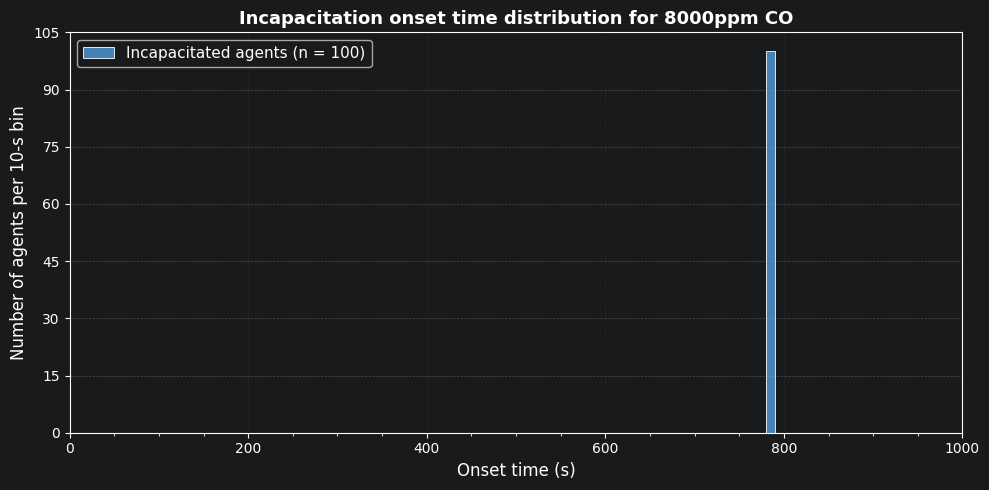

In [28]:
BIN_WIDTH = 10  # s per bin — adjust as needed

t_min = onset_df["onset_time_s"].min()
t_max = onset_df["onset_time_s"].max()
bins = np.arange(np.floor(t_min / BIN_WIDTH) * BIN_WIDTH, t_max + BIN_WIDTH, BIN_WIDTH)

fig, ax = plt.subplots(figsize=(10, 5))

counts, edges, patches = ax.hist(
    onset_df["onset_time_s"],
    bins=bins,
    color="steelblue",
    edgecolor="white",
    linewidth=0.6,
    label=f"Incapacitated agents (n = {n_onset})",
)

ax.set_xlabel("Onset time (s)", fontsize=12)
ax.set_ylabel(f"Number of agents per {BIN_WIDTH}-s bin", fontsize=12)
ax.set_title(
    "Incapacitation onset time distribution for 8000ppm CO",
    fontsize=13,
    fontweight="bold",
)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.35, linestyle="--")
ax.grid(axis="x", alpha=0.15, linestyle=":")
plt.xlim(0, 1000)

fig.tight_layout()
plt.savefig("onset_histogram.png", dpi=150)
plt.show()

## 4 — Cumulative incapacitation curve

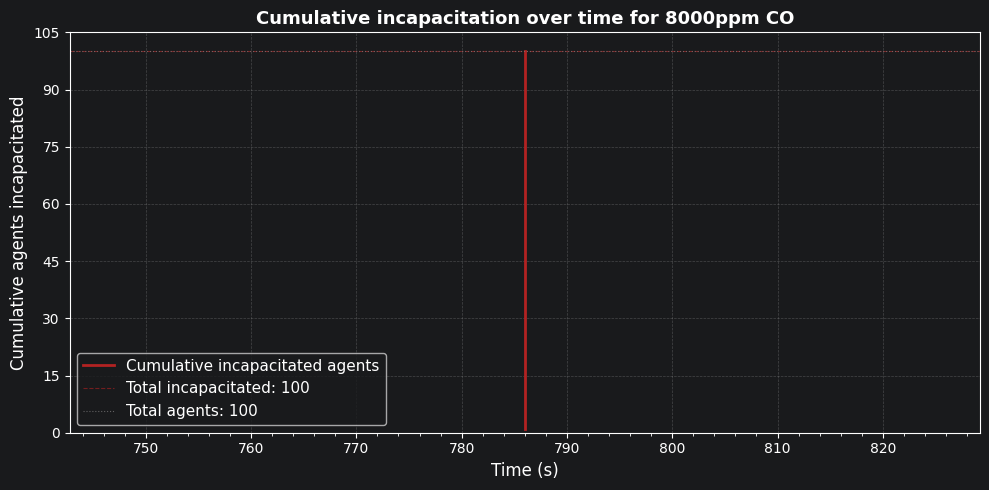

In [29]:
# Step function: cumulative count of incapacitated agents over time
t_sorted = onset_df["onset_time_s"].sort_values().values
cumulative = np.arange(1, len(t_sorted) + 1)

fig, ax = plt.subplots(figsize=(10, 5))

ax.step(
    t_sorted,
    cumulative,
    where="post",
    color="firebrick",
    linewidth=2,
    label="Cumulative incapacitated agents",
)
ax.axhline(
    n_onset,
    color="firebrick",
    linestyle="--",
    linewidth=0.8,
    alpha=0.6,
    label=f"Total incapacitated: {n_onset}",
)
ax.axhline(
    n_total,
    color="grey",
    linestyle=":",
    linewidth=0.8,
    alpha=0.7,
    label=f"Total agents: {n_total}",
)

ax.set_xlabel("Time (s)", fontsize=12)
ax.set_ylabel("Cumulative agents incapacitated", fontsize=12)
ax.set_title(
    "Cumulative incapacitation over time for 8000ppm CO", fontsize=13, fontweight="bold"
)
ax.set_ylim(0, n_total * 1.05)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.legend(fontsize=11)
ax.grid(alpha=0.3, linestyle="--")

fig.tight_layout()
plt.savefig("onset_cumulative.png", dpi=150)
plt.show()

## 5 — Summary statistics

In [30]:
stats = onset_df["onset_time_s"].describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90])
print(stats.to_string())

count    100.0
mean     786.0
std        0.0
min      786.0
10%      786.0
25%      786.0
50%      786.0
75%      786.0
90%      786.0
max      786.0


## 6 — Theoretical vs. empirical incapacitation threshold

Probabilistic mode draws each agent's own FED incapacitation threshold from
`D_incap = fed_threshold * exp(susceptibility_sigma * Z)`, `Z ~ N(0,1)` — a log-normal
with median `fed_threshold`. That per-agent draw is never written to the CSV, but it can be
recovered: incapacitation triggers exactly when `fed_cumulative >= D_incap`, so each agent's
`fed_cumulative` at their onset row **is** their threshold (to within one timestep).

Set `FED_THRESHOLD` / `SUSCEPTIBILITY_SIGMA` below to match what the run was launched with
(webapp/CLI defaults: 1.0 / 0.94) — these aren't stored in the output, so they have to be
supplied here. Leave `SUSCEPTIBILITY_SIGMA = None` if the run used deterministic mode.

In [ ]:
from scipy import stats as sps

FED_THRESHOLD = 1.0  # median threshold used for this run
SUSCEPTIBILITY_SIGMA = (
    0.94  # log-scale sigma; None => deterministic mode (skip overlay)
)

In [ ]:
# Recover each agent's empirical threshold: fed_cumulative at their onset row.
# Agents who never flip to incapacitated are tracked separately (see below) —
# their true threshold is unknown, only that it exceeds whatever FED they reached.
threshold_rows = []
never_incap_max_fed = []
for agent_id, group in df.groupby("agent_id"):
    group = group.sort_values("time_s")
    incap = group["incapacitated"].astype(bool)
    mask = incap & ~incap.shift(1, fill_value=False)
    onset_rows = group[mask]
    if not onset_rows.empty:
        threshold_rows.append(
            {
                "agent_id": agent_id,
                "empirical_threshold": onset_rows["fed_cumulative"].iloc[0],
            }
        )
    else:
        never_incap_max_fed.append(group["fed_cumulative"].max())

threshold_df = pd.DataFrame(threshold_rows)
print(f"Recovered thresholds for {len(threshold_df)} / {n_total} agents")
threshold_df["empirical_threshold"].describe()

### Why this needs right-truncation, not a raw overlay

`empirical_threshold` only exists for agents that actually flipped `incapacitated = True`.
Any agent whose *drawn* threshold happened to land above the maximum FED this exposure
ever delivers is invisible to this recovery method — it never crosses, so there's no onset
row to read a threshold off of. That's **right-truncation**: the sample silently excludes
everything above a ceiling, rather than partially recording it (which would instead be
*censoring*, e.g. "threshold ≥ ceiling" — not the case here, since we simply have no row).

Comparing that truncated sample to the raw, unconditional log-normal will always look wrong
in the tail — not because the sampling code is broken, but because this scenario's exposure
never gets severe/long enough to expose agents past the ceiling. The statistically correct
comparison is the log-normal **renormalized over the observable range**:

$$f_{	ext{trunc}}(x) = \dfrac{f(x)}{F(	ext{ceiling})}, \quad x \le 	ext{ceiling}$$

using the parent log-normal's PDF `f` and CDF `F`. This is the standard right-truncated-
distribution technique from reliability/survival analysis, applied here under the
assumption (reasonable for a homogeneous-exposure scenario) that every agent shares roughly
the same FED ceiling — for scenarios with widely varying per-agent exposure, a single global
ceiling is only an approximation.

In [ ]:
n_never = len(never_incap_max_fed)
if n_never:
    fed_ceiling = max(never_incap_max_fed)
    print(
        f"Censored (never crossed their threshold): {n_never} / {n_total} "
        f"({100 * n_never / n_total:.1f}%)"
    )
    print(f"FED ceiling this exposure ever delivers:    {fed_ceiling:.3f}")
else:
    fed_ceiling = None
    print(
        "No censoring — every agent crossed their threshold; raw log-normal is a valid comparison."
    )

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

vals = threshold_df["empirical_threshold"].values
hi = max(vals.max(), fed_ceiling or 0) * 1.15
bins = np.linspace(max(vals.min() * 0.5, 1e-6), hi, 30)

ax.hist(
    vals,
    bins=bins,
    density=True,
    color="steelblue",
    edgecolor="white",
    linewidth=0.6,
    alpha=0.75,
    label=f"Empirical thresholds (n = {len(vals)})",
)

if SUSCEPTIBILITY_SIGMA:
    dist = sps.lognorm(s=SUSCEPTIBILITY_SIGMA, scale=FED_THRESHOLD)
    x = np.linspace(bins[0], bins[-1], 400)

    if fed_ceiling is not None:
        norm = dist.cdf(fed_ceiling)
        pdf_trunc = np.where(x <= fed_ceiling, dist.pdf(x) / norm, 0.0)
        ax.plot(
            x,
            pdf_trunc,
            color="firebrick",
            linewidth=2,
            label=f"Log-normal, truncated at FED={fed_ceiling:.2f} ({100 * n_never / n_total:.0f}% censored)",
        )
        ax.axvline(
            fed_ceiling,
            color="grey",
            linestyle=":",
            linewidth=1,
            label="Exposure ceiling (max FED ever reached)",
        )
        ax.plot(
            x,
            dist.pdf(x),
            color="firebrick",
            linewidth=1.2,
            linestyle="--",
            alpha=0.5,
            label="Raw log-normal (untruncated, for reference)",
        )
    else:
        ax.plot(
            x,
            dist.pdf(x),
            color="firebrick",
            linewidth=2,
            label=f"Theoretical log-normal (median={FED_THRESHOLD}, sigma={SUSCEPTIBILITY_SIGMA})",
        )

ax.set_xlabel("FED incapacitation threshold", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title(
    "Incapacitation threshold: theoretical vs. simulated",
    fontsize=13,
    fontweight="bold",
)
ax.legend(fontsize=9.5)
ax.grid(axis="y", alpha=0.3, linestyle="--")

fig.tight_layout()
plt.savefig("threshold_distribution.png", dpi=150)
plt.show()